In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import cobra
import numpy as np
import pandas as pd

MODEL_PATH = Path("../model/Rpom_05.xml")
TARGET_MU = 0.22
GLUCOSE_UPTAKE = -5.44
ACETATE_UPTAKE = -15.01
BASELINE_ATPM = 3.15
ATPM_SCAN_MAX = 80.0


@dataclass
class Scenario:
    name: str
    setup: Callable[[cobra.Model], None] | None = None


def configure_carbon(model: cobra.Model, glucose: float, acetate: float) -> None:
    model.reactions.get_by_id("EX_glc").bounds = (glucose, 0.0) if glucose < 0 else (0.0, 0.0)
    model.reactions.get_by_id("EX_ac").bounds = (acetate, 0.0) if acetate < 0 else (0.0, 0.0)


def growth_rate(model: cobra.Model, atpm: float) -> float:
    model.reactions.get_by_id("ATPM").bounds = (atpm, atpm)
    sol = model.optimize()
    return float(sol.objective_value or 0.0)


def atpm_for_target_mu(
    model: cobra.Model,
    glucose: float,
    acetate: float,
    target_mu: float = TARGET_MU,
    lo: float = 0.0,
    hi: float = ATPM_SCAN_MAX,
) -> float:
    configure_carbon(model, glucose, acetate)

    mu_lo = growth_rate(model, lo)
    mu_hi = growth_rate(model, hi)
    if (mu_lo - target_mu) * (mu_hi - target_mu) > 0:
        return float("nan")

    for _ in range(60):
        mid = 0.5 * (lo + hi)
        mu_mid = growth_rate(model, mid)
        if (mu_lo - target_mu) * (mu_mid - target_mu) <= 0:
            hi = mid
            mu_hi = mu_mid
        else:
            lo = mid
            mu_lo = mu_mid
    return 0.5 * (lo + hi)


def set_biomass_gam(model: cobra.Model, atp_coeff: float) -> None:
    biomass = model.reactions.get_by_id("Rpom_hwa_biomass")
    atp = model.metabolites.get_by_id("ATP[c]")
    adp = model.metabolites.get_by_id("ADP[c]")
    pi = model.metabolites.get_by_id("Pi[c]")
    h = model.metabolites.get_by_id("PROTON[c]")

    current = -biomass.metabolites[atp]
    delta = atp_coeff - current
    biomass.add_metabolites({atp: -delta, adp: delta, pi: delta, h: delta})


def scenario_ppdk_forward_only(model: cobra.Model) -> None:
    model.reactions.get_by_id("PYRUVATEORTHOPHOSPHATE-DIKINASE-RXN").lower_bound = 0.0


def scenario_disable_ed(model: cobra.Model) -> None:
    for rid in [
        "GLU6PDEHYDROG-RXN",
        "6PGLUCONOLACT-RXN",
        "PGLUCONDEHYDRAT-RXN",
        "KDPGALDOL-RXN",
    ]:
        model.reactions.get_by_id(rid).knock_out()


def scenario_disable_complex_i(model: cobra.Model) -> None:
    model.reactions.get_by_id("NADH-DEHYDROG-A-RXN").knock_out()


def scenario_non_pumping_complex_i(model: cobra.Model) -> None:
    # Approximate NDH-II/NQR-like NADH oxidation by removing proton translocation from NDH-I.
    rxn = model.reactions.get_by_id("NADH-DEHYDROG-A-RXN")
    rxn.subtract_metabolites(dict(rxn.metabolites))
    rxn.add_metabolites(
        {
            model.metabolites.get_by_id("NADH[c]"): -1.0,
            model.metabolites.get_by_id("PROTON[c]"): -1.0,
            model.metabolites.get_by_id("UBIQUINONE-10[c]"): -1.0,
            model.metabolites.get_by_id("CPD-9958[c]"): 1.0,
            model.metabolites.get_by_id("NAD[c]"): 1.0,
        }
    )
    rxn.bounds = (0.0, 1000.0)


def scenario_gam50(model: cobra.Model) -> None:
    set_biomass_gam(model, atp_coeff=50.0)


def scenario_complex_i_less_coupled_plus_gam50(model: cobra.Model) -> None:
    scenario_non_pumping_complex_i(model)
    scenario_gam50(model)


def evaluate_scenario(base_model: cobra.Model, scenario: Scenario) -> dict[str, float | str]:
    with base_model:
        if scenario.setup is not None:
            scenario.setup(base_model)

        configure_carbon(base_model, GLUCOSE_UPTAKE, 0.0)
        mu_glc_at_baseline_atpm = growth_rate(base_model, BASELINE_ATPM)

        configure_carbon(base_model, 0.0, ACETATE_UPTAKE)
        mu_ac_at_baseline_atpm = growth_rate(base_model, BASELINE_ATPM)

        configure_carbon(base_model, GLUCOSE_UPTAKE, 0.0)
        atpm_for_target = atpm_for_target_mu(base_model, GLUCOSE_UPTAKE, 0.0, target_mu=TARGET_MU)

    return {
        "scenario": scenario.name,
        "mu_glc_at_ATPM3.15": mu_glc_at_baseline_atpm,
        "mu_ac_at_ATPM3.15": mu_ac_at_baseline_atpm,
        "ATPM_for_mu0.22_glc": atpm_for_target,
    }


def main() -> None:
    model = cobra.io.read_sbml_model(str(MODEL_PATH))

    scenarios = [
        Scenario("baseline", None),
        Scenario("PPDK_forward_only", scenario_ppdk_forward_only),
        Scenario("ED_pathway_disabled", scenario_disable_ed),
        Scenario("ComplexI_disabled", scenario_disable_complex_i),
        Scenario("ComplexI_non_pumping", scenario_non_pumping_complex_i),
        Scenario("GAM_50ATP", scenario_gam50),
        Scenario("ComplexI_non_pumping_plus_GAM_50ATP", scenario_complex_i_less_coupled_plus_gam50),
    ]

    rows = [evaluate_scenario(model, s) for s in scenarios]
    df = pd.DataFrame(rows).sort_values("ATPM_for_mu0.22_glc")

    out_dir = Path("analysis/glucose_overgrowth_20260305")
    out_dir.mkdir(parents=True, exist_ok=True)

    out_csv = out_dir / "hypothesis_summary.csv"
    df.to_csv(out_csv, index=False)

    print("Saved:", out_csv)
    print(df.to_string(index=False))

    # One focused diagnostic: ATP-producing reactions on glucose at baseline.
    with model:
        configure_carbon(model, GLUCOSE_UPTAKE, 0.0)
        model.reactions.get_by_id("ATPM").bounds = (BASELINE_ATPM, BASELINE_ATPM)
        sol = cobra.flux_analysis.pfba(model)
        atp = model.metabolites.get_by_id("ATP[c]")
        records = []
        for rxn in atp.reactions:
            net = rxn.metabolites[atp] * sol.fluxes[rxn.id]
            if abs(net) > 1e-6:
                records.append((rxn.id, float(sol.fluxes[rxn.id]), float(net)))
        atp_df = pd.DataFrame(records, columns=["reaction", "flux", "ATP_net"])
        atp_out = out_dir / "atp_budget_glucose_baseline.csv"
        atp_df.sort_values("ATP_net", ascending=False).to_csv(atp_out, index=False)
        print("Saved:", atp_out)

In [2]:
main()

/Users/acheron/micromamba/envs/rpom/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Saved: analysis/glucose_overgrowth_20260305/hypothesis_summary.csv
                           scenario  mu_glc_at_ATPM3.15  mu_ac_at_ATPM3.15  ATPM_for_mu0.22_glc
                ED_pathway_disabled            0.228739           0.397625             4.239496
ComplexI_non_pumping_plus_GAM_50ATP            0.428995           0.308329            24.624922
                  ComplexI_disabled            0.486573           0.348933            28.725327
               ComplexI_non_pumping            0.486573           0.348933            28.725327
                          GAM_50ATP            0.509365           0.358625            41.348526
                  PPDK_forward_only            0.558735           0.349618            44.965317
                           baseline            0.566072           0.397625            45.448931
Saved: analysis/glucose_overgrowth_20260305/atp_budget_glucose_baseline.csv


In [3]:
import sys
from helpers import *
if ".." not in sys.path:
    sys.path.append("..")
    
import cobra
import pandas as pd
from cobra.io import read_sbml_model
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

model = read_sbml_model("../model/Rpom_05.xml")
model



Name,Rpom_05
Memory address,338e03580
Number of metabolites,1797
Number of reactions,1799
Number of genes,984
Number of groups,0
Objective expression,1.0*Rpom_hwa_biomass - 1.0*Rpom_hwa_biomass_reverse_5ec2f
Compartments,"c, p, e"


In [4]:
model.reactions.get_by_id("NADH-DEHYDROG-A-RXN")

Reaction identifier,NADH-DEHYDROG-A-RXN
Name,
Memory address,0x343024940
Stoichiometry,NADH[c] + 5.0 PROTON[c] + UBIQUINONE-10[c] <=> CPD-9958[c] + NAD[c] + 4.0 PROTON[p] NADH + 5.0 H+ + ubiquinone-10 <=> ubiquinol-10 + NAD+ + 4.0 H+
GPR,SPO2786 and SPO2785 and SPO2782 and SPO2774 and SPO2772 and SPO2770 and SPO2767 and SPO2766 and...
Lower bound,-1000.0
Upper bound,1000.0


# as is

In [13]:
ATPM_space = np.linspace(0,50,100)
growth_rates = []
growth_rates_ac = []

with model:
    # =====================================================================
    # COMMON METABOLITES
    # =====================================================================
    WATER = model.metabolites.get_by_id("WATER[c]")
    Pi = model.metabolites.get_by_id("Pi[c]")
    PROTON = model.metabolites.get_by_id("PROTON[c]")
    G3P = model.metabolites.get_by_id("GLYCEROL-3P[c]")
    CTP = model.metabolites.get_by_id("CTP[c]")
    PPI = model.metabolites.get_by_id("PPI[c]")
    CMP = model.metabolites.get_by_id("CMP[c]")
    SER = model.metabolites.get_by_id("SER[c]")
    CO2 = model.metabolites.get_by_id("CARBON-DIOXIDE[c]")
    COA = model.metabolites.get_by_id("CO-A[c]")
    ATP = model.metabolites.get_by_id("ATP[c]")
    ADP = model.metabolites.get_by_id("ADP[c]")
    NADH = model.metabolites.get_by_id("NADH[c]")
    NAD = model.metabolites.get_by_id("NAD[c]")
    O2 = model.metabolites.get_by_id("OXYGEN-MOLECULE[c]")
    orn = model.metabolites.get_by_id("L-ORNITHINE[c]")
    gln = model.metabolites.get_by_id("GLN[c]")
    ACP = model.metabolites.get_by_id("ACP[c]")
    
    # =====================================================================
    # TEST GROWTH
    # =====================================================================
    model.objective = "Rpom_hwa_biomass"
    
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    sol_glc = model.optimize()
    print(f"\nGlucose growth: {sol_glc.objective_value:.4f}")
    
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac = model.optimize()
    print(f"Acetate growth:  {sol_ac.objective_value:.4f}")
    
    print("ratio: ", sol_glc.objective_value / sol_ac.objective_value)
    
    for level in tqdm(ATPM_space):
        model.reactions.get_by_id("ATPM").bounds = (level, level)
        model.reactions.get_by_id("EX_ac").bounds = (0, 0)
        model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
        sol = model.optimize()
        growth_rates.append(sol.objective_value)
    
    for level in tqdm(ATPM_space):
        model.reactions.get_by_id("ATPM").bounds = (level, level)
        model.reactions.get_by_id("EX_glc").bounds = (0, 0)
        model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
        sol = model.optimize()
        growth_rates_ac.append(sol.objective_value)


Glucose growth: 0.5849
Acetate growth:  0.4160
ratio:  1.405962907265684


 88%|████████▊ | 88/100 [00:00<00:00, 128.79it/s]/Users/acheron/micromamba/envs/rpom/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
100%|██████████| 100/100 [00:00<00:00, 103.88it/s]


/var/folders/8f/167j3z857g1cpb6_79vckdjc0000gn/T/ipykernel_66528/1488089653.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


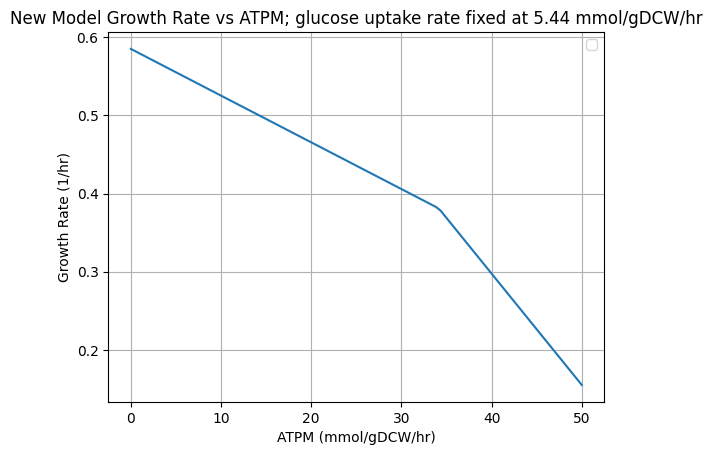

In [14]:
plt.plot(ATPM_space, growth_rates)
plt.title("New Model Growth Rate vs ATPM; glucose uptake rate fixed at 5.44 mmol/gDCW/hr")
plt.xlabel("ATPM (mmol/gDCW/hr)")
plt.ylabel("Growth Rate (1/hr)")
plt.grid()
plt.legend()
plt.show()


/var/folders/8f/167j3z857g1cpb6_79vckdjc0000gn/T/ipykernel_66528/2225254439.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


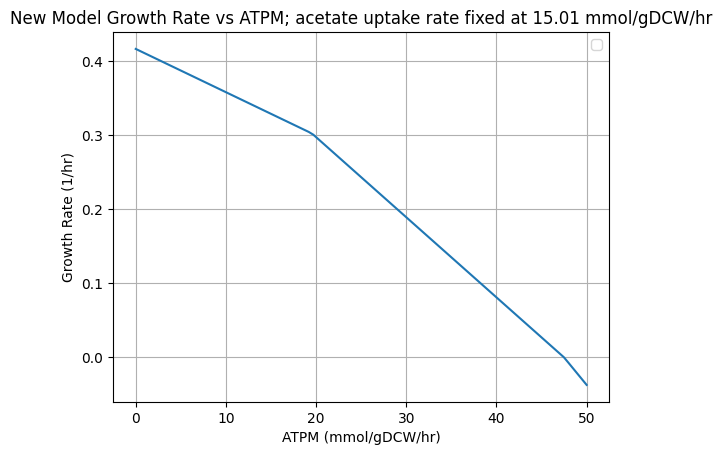

In [10]:
plt.plot(ATPM_space, growth_rates_ac)
plt.title("New Model Growth Rate vs ATPM; acetate uptake rate fixed at 15.01 mmol/gDCW/hr")
plt.xlabel("ATPM (mmol/gDCW/hr)")
plt.ylabel("Growth Rate (1/hr)")
plt.grid()
plt.legend()
plt.show()


# hypothesis 1:

In [35]:
ATPM_space = np.linspace(0,50,100)
growth_rates = []
growth_rates_ac = []

with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    
    # =====================================================================
    # COMMON METABOLITES
    # =====================================================================
    WATER = model.metabolites.get_by_id("WATER[c]")
    Pi = model.metabolites.get_by_id("Pi[c]")
    PROTON = model.metabolites.get_by_id("PROTON[c]")
    G3P = model.metabolites.get_by_id("GLYCEROL-3P[c]")
    CTP = model.metabolites.get_by_id("CTP[c]")
    PPI = model.metabolites.get_by_id("PPI[c]")
    CMP = model.metabolites.get_by_id("CMP[c]")
    SER = model.metabolites.get_by_id("SER[c]")
    CO2 = model.metabolites.get_by_id("CARBON-DIOXIDE[c]")
    COA = model.metabolites.get_by_id("CO-A[c]")
    ATP = model.metabolites.get_by_id("ATP[c]")
    ADP = model.metabolites.get_by_id("ADP[c]")
    NADH = model.metabolites.get_by_id("NADH[c]")
    NAD = model.metabolites.get_by_id("NAD[c]")
    O2 = model.metabolites.get_by_id("OXYGEN-MOLECULE[c]")
    orn = model.metabolites.get_by_id("L-ORNITHINE[c]")
    gln = model.metabolites.get_by_id("GLN[c]")
    ACP = model.metabolites.get_by_id("ACP[c]")
    
    # =====================================================================
    # Fix NADH dehydrogenase (e → p)
    # =====================================================================
    model.reactions.get_by_id("NADH-DEHYDROG-A-RXN").knock_out()
    rxn_ndh = cobra.Reaction("NADH-DEHYDROG-A-RXN_2")
    rxn_ndh.add_metabolites({
        NADH: -1, 
        model.metabolites.get_by_id("PROTON[c]"): -1,
        model.metabolites.get_by_id("UBIQUINONE-10[c]"): -1,
        model.metabolites.get_by_id("CPD-9958[c]"): 1, 
        NAD: 1
        #model.metabolites.get_by_id("PROTON[p]"): 0
    })
    rxn_ndh.bounds = (0, 1000)
    model.add_reactions([rxn_ndh])

    # =====================================================================
    # TEST GROWTH
    # =====================================================================
    model.objective = "Rpom_hwa_biomass"
    
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    sol_glc = model.optimize()
    print(f"\nGlucose growth: {sol_glc.objective_value:.4f}")
    
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac = model.optimize()
    print(f"Acetate growth:  {sol_ac.objective_value:.4f}")
    
    print("ratio: ", sol_glc.objective_value / sol_ac.objective_value)
    
    for level in tqdm(ATPM_space):
        model.reactions.get_by_id("ATPM").bounds = (level, level)
        model.reactions.get_by_id("EX_ac").bounds = (0, 0)
        model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
        sol = model.optimize()
        growth_rates.append(sol.objective_value)
    
    for level in tqdm(ATPM_space):
        model.reactions.get_by_id("ATPM").bounds = (level, level)
        model.reactions.get_by_id("EX_glc").bounds = (0, 0)
        model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
        sol = model.optimize()
        growth_rates_ac.append(sol.objective_value)


Glucose growth: 0.4808
Acetate growth:  0.3507
ratio:  1.3710291100027399


100%|██████████| 100/100 [00:01<00:00, 54.96it/s]


In [36]:
model.metabolites.get_by_id("CPD-9958[c]")

Metabolite identifier,CPD-9958[c]
Name,ubiquinol-10
Memory address,0x3452db430
Formula,C59H92O4
Compartment,c
In 7 reaction(s),"1.10.2.2-RXN, RXN-14903, SUCCINATE-DEHYDROGENASE-UBIQUINONE-RXN, RXN-20992, 1.5.5.1-RXN-ETF-Reduced/UBIQUINONE-10//ETF-Oxidized/CPD-9958/PROTON.56., NADH-DEHYDROG-A-RXN, RXN-9237"


/var/folders/8f/167j3z857g1cpb6_79vckdjc0000gn/T/ipykernel_20981/1488089653.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


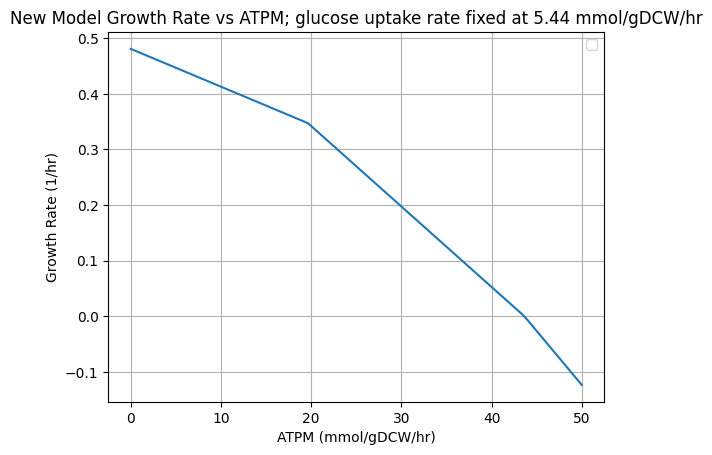

In [32]:
plt.plot(ATPM_space, growth_rates)
plt.title("New Model Growth Rate vs ATPM; glucose uptake rate fixed at 5.44 mmol/gDCW/hr")
plt.xlabel("ATPM (mmol/gDCW/hr)")
plt.ylabel("Growth Rate (1/hr)")
plt.grid()
plt.legend()
plt.show()


/var/folders/8f/167j3z857g1cpb6_79vckdjc0000gn/T/ipykernel_20981/2225254439.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


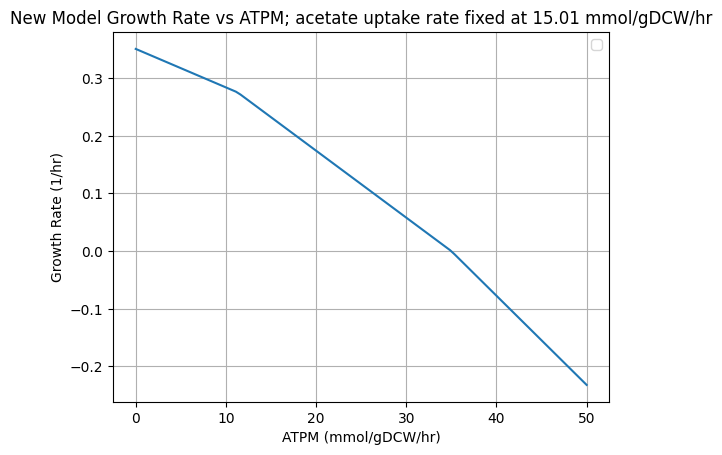

In [30]:
plt.plot(ATPM_space, growth_rates_ac)
plt.title("New Model Growth Rate vs ATPM; acetate uptake rate fixed at 15.01 mmol/gDCW/hr")
plt.xlabel("ATPM (mmol/gDCW/hr)")
plt.ylabel("Growth Rate (1/hr)")
plt.grid()
plt.legend()
plt.show()


In [11]:
def summarize_hypothesis_scenario(name: str, setup: Callable[[cobra.Model], None]) -> dict[str, float | str]:
    with cobra.io.read_sbml_model(str(MODEL_PATH)) as hypothesis_model:
        setup(hypothesis_model)

        configure_carbon(hypothesis_model, GLUCOSE_UPTAKE, 0.0)
        glucose_growth = growth_rate(hypothesis_model, BASELINE_ATPM)
        glucose_atpm = atpm_for_target_mu(hypothesis_model, GLUCOSE_UPTAKE, 0.0, target_mu=TARGET_MU)

        configure_carbon(hypothesis_model, 0.0, ACETATE_UPTAKE)
        acetate_growth = growth_rate(hypothesis_model, BASELINE_ATPM)
        acetate_atpm = atpm_for_target_mu(hypothesis_model, 0.0, ACETATE_UPTAKE, target_mu=TARGET_MU)

    return {
        "scenario": name,
        "glucose_ATPM_at_mu0.22": glucose_atpm,
        "glucose_growth_at_5.44": glucose_growth,
        "acetate_ATPM_at_mu0.22": acetate_atpm,
        "acetate_growth_at_15.01": acetate_growth,
    }


hypothesis_results = pd.DataFrame(
    [
        summarize_hypothesis_scenario("ED_pathway_disabled", scenario_disable_ed),
        summarize_hypothesis_scenario("ComplexI_non_pumping", scenario_non_pumping_complex_i),
    ]
).set_index("scenario")

print(hypothesis_results.to_string())

ed = hypothesis_results.loc["ED_pathway_disabled"]
ci = hypothesis_results.loc["ComplexI_non_pumping"]

print(
    "Glucose growth might be too dependent on Entner-Doudoroff flux. "
    f"Full ED knockout moves glucose ATPM to {ed['glucose_ATPM_at_mu0.22']:.2f} (at 0.22/hr) "
    f"and growth to {ed['glucose_growth_at_5.44']:.3f} (at 5.44 mmol/gDCW/hr). "
    f"Acetate ATPM to {ed['acetate_ATPM_at_mu0.22']:.2f} (at 0.22/hr) "
    f"and growth to {ed['acetate_growth_at_15.01']:.3f} (at 15.01 mmol/gDCW/hr)."
)

print()

print(
    "Respiratory over-coupling: the model may be giving too much ATP from NADH oxidation via Complex I. "
    f"Making NADH-DEHYDROG-A-RXN non-pumping moves glucose ATPM to {ci['glucose_ATPM_at_mu0.22']:.2f} (at 0.22/hr) "
    f"and growth to {ci['glucose_growth_at_5.44']:.3f} (at 5.44 mmol/gDCW/hr). "
    f"Acetate ATPM to {ci['acetate_ATPM_at_mu0.22']:.2f} (at 0.22/hr) "
    f"and growth to {ci['acetate_growth_at_15.01']:.3f} (at 15.01 mmol/gDCW/hr)."
)


                      glucose_ATPM_at_mu0.22  glucose_growth_at_5.44  acetate_ATPM_at_mu0.22  acetate_growth_at_15.01
scenario                                                                                                             
ED_pathway_disabled                 4.239496                0.228739               27.131885                 0.397625
ComplexI_non_pumping               28.725327                0.486573               16.637584                 0.348933
Glucose growth might be too dependent on Entner-Doudoroff flux. Full ED knockout moves glucose ATPM to 4.24 (at 0.22/hr) and growth to 0.229 (at 5.44 mmol/gDCW/hr). Acetate ATPM to 27.13 (at 0.22/hr) and growth to 0.398 (at 15.01 mmol/gDCW/hr).

Respiratory over-coupling: the model may be giving too much ATP from NADH oxidation via Complex I. Making NADH-DEHYDROG-A-RXN non-pumping moves glucose ATPM to 28.73 (at 0.22/hr) and growth to 0.487 (at 5.44 mmol/gDCW/hr). Acetate ATPM to 16.64 (at 0.22/hr) and growth to 0.349 (at 

## Lipid Rescue Sensitivity

The corrected `LIPID-RXN` in `model_building/reactions/corrections` expands the biomass lipid pseudoreaction into specific membrane lipid species. To test whether any one lipid requirement is especially growth-limiting, add a free source for each lipid component one-at-a-time and re-evaluate:

- glucose growth at the standard glucose uptake rate (`5.44 mmol/gDCW/hr`) with `ATPM = 3.15`
- acetate growth at the standard acetate uptake rate (`15.01 mmol/gDCW/hr`) with `ATPM = 3.15`
- the maximum ATPM compatible with `mu = 0.22 /hr` on glucose
- the maximum ATPM compatible with `mu = 0.22 /hr` on acetate

Positive deltas mean that externally supplying that lipid relaxes a biosynthetic burden and improves the phenotype.


/Users/acheron/micromamba/envs/rpom/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Baseline lipid-constrained state:
lipid                            NaN
species                          NaN
compartment                      NaN
glucose_growth_at_5.44      0.566072
glucose_ATPM_at_mu0.22     45.448931
acetate_growth_at_15.01     0.397625
acetate_ATPM_at_mu0.22     27.131885

Top lipid rescues by combined growth improvement:
          lipid      species compartment  delta_glucose_growth_at_5.44  delta_acetate_growth_at_15.01  delta_glucose_ATPM_at_mu0.22  delta_acetate_ATPM_at_mu0.22
      PG-C18[c]       PG-C18           c                      0.029883                       0.020753                      0.252701                      0.577499
      PE-C18[c]       PE-C18           c                      0.010287                       0.007149                      0.088063                      0.204201
    MMPE-C18[c]     MMPE-C18           c                      0.008003                       0.005588                      0.068619                      0.161788
      PG

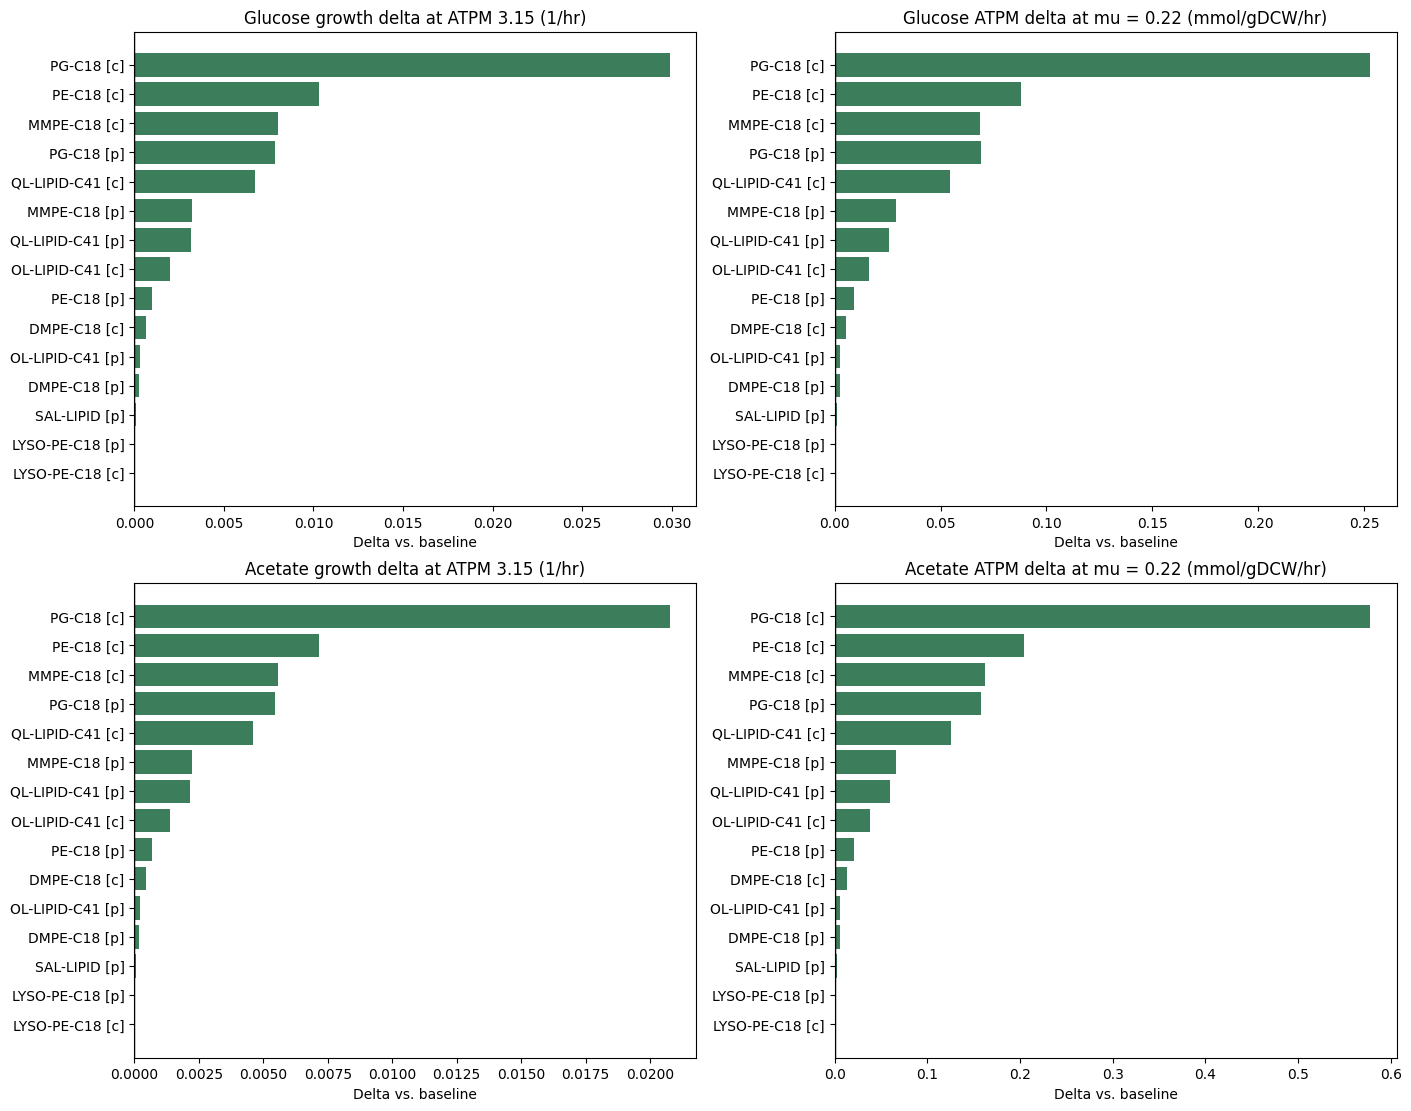


Most impactful single rescue: PG-C18[c]. It increases glucose growth by 0.030 /hr and acetate growth by 0.021 /hr, while also raising the ATPM compatible with mu = 0.22 by 0.25 on glucose and 0.58 on acetate.


In [12]:
import matplotlib.pyplot as plt


def lipid_species_name(metabolite_id: str) -> str:
    return metabolite_id.split("[")[0]


def lipid_compartment(metabolite_id: str) -> str:
    return metabolite_id.split("[")[1].rstrip("]")


def lipid_components_from_biomass(model: cobra.Model) -> list[str]:
    lipid_rxn = model.reactions.get_by_id("LIPID-RXN")
    return [met.id for met, coeff in lipid_rxn.metabolites.items() if coeff < 0]


def add_free_source(model: cobra.Model, metabolite_id: str, upper_bound: float = 1000.0) -> None:
    source = cobra.Reaction(f"SOURCE_{metabolite_id}")
    source.add_metabolites({model.metabolites.get_by_id(metabolite_id): 1.0})
    source.bounds = (0.0, upper_bound)
    model.add_reactions([source])


def evaluate_media_state(model: cobra.Model, glucose: float, acetate: float) -> tuple[float, float]:
    configure_carbon(model, glucose, acetate)
    growth = growth_rate(model, BASELINE_ATPM)
    atpm = atpm_for_target_mu(model, glucose, acetate, target_mu=TARGET_MU)
    return growth, atpm


def evaluate_lipid_source_effect(metabolite_id: str | None = None) -> dict[str, float | str | None]:
    with cobra.io.read_sbml_model(str(MODEL_PATH)) as lipid_model:
        lipid_model.objective = "Rpom_hwa_biomass"
        if metabolite_id is not None:
            add_free_source(lipid_model, metabolite_id)

        glucose_growth, glucose_atpm = evaluate_media_state(lipid_model, GLUCOSE_UPTAKE, 0.0)
        acetate_growth, acetate_atpm = evaluate_media_state(lipid_model, 0.0, ACETATE_UPTAKE)

    return {
        "lipid": metabolite_id,
        "species": None if metabolite_id is None else lipid_species_name(metabolite_id),
        "compartment": None if metabolite_id is None else lipid_compartment(metabolite_id),
        "glucose_growth_at_5.44": glucose_growth,
        "glucose_ATPM_at_mu0.22": glucose_atpm,
        "acetate_growth_at_15.01": acetate_growth,
        "acetate_ATPM_at_mu0.22": acetate_atpm,
    }


baseline_lipid_state = evaluate_lipid_source_effect(None)
baseline_lipid_state

with cobra.io.read_sbml_model(str(MODEL_PATH)) as lipid_scan_model:
    lipid_ids = lipid_components_from_biomass(lipid_scan_model)

lipid_rescue_results = pd.DataFrame(
    [evaluate_lipid_source_effect(metabolite_id) for metabolite_id in lipid_ids]
)

for metric in [
    "glucose_growth_at_5.44",
    "glucose_ATPM_at_mu0.22",
    "acetate_growth_at_15.01",
    "acetate_ATPM_at_mu0.22",
]:
    lipid_rescue_results[f"delta_{metric}"] = lipid_rescue_results[metric] - baseline_lipid_state[metric]

lipid_rescue_results["combined_growth_delta"] = (
    lipid_rescue_results["delta_glucose_growth_at_5.44"]
    + lipid_rescue_results["delta_acetate_growth_at_15.01"]
)
lipid_rescue_results["combined_ATPM_delta"] = (
    lipid_rescue_results["delta_glucose_ATPM_at_mu0.22"]
    + lipid_rescue_results["delta_acetate_ATPM_at_mu0.22"]
)

lipid_rescue_results = lipid_rescue_results.sort_values("combined_growth_delta", ascending=False)
print("Baseline lipid-constrained state:")
print(pd.Series(baseline_lipid_state).to_string())
print()
print("Top lipid rescues by combined growth improvement:")
print(
    lipid_rescue_results[
        [
            "lipid",
            "species",
            "compartment",
            "delta_glucose_growth_at_5.44",
            "delta_acetate_growth_at_15.01",
            "delta_glucose_ATPM_at_mu0.22",
            "delta_acetate_ATPM_at_mu0.22",
        ]
    ]
    .head(10)
    .to_string(index=False)
)

species_summary = (
    lipid_rescue_results.groupby("species", as_index=False)[
        [
            "combined_growth_delta",
            "combined_ATPM_delta",
            "delta_glucose_growth_at_5.44",
            "delta_acetate_growth_at_15.01",
        ]
    ]
    .max()
    .sort_values("combined_growth_delta", ascending=False)
)
print()
print("Species-level summary (best compartment-specific rescue per species):")
print(species_summary.to_string(index=False))

plot_order = lipid_rescue_results.sort_values("combined_growth_delta", ascending=True)
labels = [f"{row.species} [{row.compartment}]" for row in plot_order.itertuples()]

fig, axes = plt.subplots(2, 2, figsize=(14, 11), constrained_layout=True)
plot_specs = [
    ("delta_glucose_growth_at_5.44", "Glucose growth delta at ATPM 3.15 (1/hr)", axes[0, 0]),
    ("delta_glucose_ATPM_at_mu0.22", "Glucose ATPM delta at mu = 0.22 (mmol/gDCW/hr)", axes[0, 1]),
    ("delta_acetate_growth_at_15.01", "Acetate growth delta at ATPM 3.15 (1/hr)", axes[1, 0]),
    ("delta_acetate_ATPM_at_mu0.22", "Acetate ATPM delta at mu = 0.22 (mmol/gDCW/hr)", axes[1, 1]),
]

for metric, title, ax in plot_specs:
    ax.barh(labels, plot_order[metric], color="#3c7d5b")
    ax.axvline(0.0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Delta vs. baseline")

plt.show()

top_hit = lipid_rescue_results.iloc[0]
print()
print(
    f"Most impactful single rescue: {top_hit['lipid']}. "
    f"It increases glucose growth by {top_hit['delta_glucose_growth_at_5.44']:.3f} /hr "
    f"and acetate growth by {top_hit['delta_acetate_growth_at_15.01']:.3f} /hr, while also raising "
    f"the ATPM compatible with mu = 0.22 by {top_hit['delta_glucose_ATPM_at_mu0.22']:.2f} on glucose "
    f"and {top_hit['delta_acetate_ATPM_at_mu0.22']:.2f} on acetate."
)
